### Notebook 6 : Logistic Regression Implementation

##### Import libraries

In [1]:
import pandas as pd
import numpy as np

##### Load data set

In [2]:
df = pd.read_csv(r'C:\Users\HP\Desktop\mini project 00\capstone.csv')

##### Data Preperation

* Drop non-numeric and irrelevant columns

In [3]:
df = df.drop(columns=["MemberName"])

* Map CourseName to numeric values

In [4]:
course_mapping = {
    'Foundations of ML': 0,
    'Production-Ready ML Systems': 1
}
df['CourseName'] = df['CourseName'].map(course_mapping)

* Separate features (X) and target (y)

In [5]:
feature_cols = [
    'EducationLevel', 'Attendance', 'TotalHours',
    'AssignmentsCompleted', 'HackathonParticipation',
    'GitHubScore', 'PeerReviewScore', 'CourseName'
]
X = df[feature_cols].values
y = df['CapstoneScore'].values

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (150, 8)
y shape: (150,)


In [6]:
# y_pass: 1 if score >= 75 else 0
y_pass = (df['CapstoneScore'] >= 75).astype(int).values
print("Class balance [fail, pass]:", np.bincount(y_pass))
print("y_pass shape:", y_pass.shape)


Class balance [fail, pass]: [102  48]
y_pass shape: (150,)


*  Feature Scaling / Standardization

* The bias (intercept) is an extra column of ones.

In [7]:
# Standardize X (feature-wise)
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0) + 1e-12
X_scaled = (X - X_mean) / X_std

# Add bias column
m = X_scaled.shape[0]
Xb = np.hstack([np.ones((m, 1)), X_scaled])

print("X_scaled shape:", X_scaled.shape)
print("Xb shape:", Xb.shape)  # (m, 1 + n_features)


X_scaled shape: (150, 8)
Xb shape: (150, 9)


* Core logistic pieces (sigmoid, loss, gradient)

In [8]:
def sigmoid(z):
    z = np.clip(z, -500, 500)          # numerical stability
    return 1.0 / (1.0 + np.exp(-z))

def logistic_loss(Xb, y, theta):
    m = y.size
    p = sigmoid(Xb @ theta)
    eps = 1e-12
    return -(1/m) * np.sum(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))

def logistic_grad(Xb, y, theta):
    m = y.size
    p = sigmoid(Xb @ theta)
    return (1/m) * (Xb.T @ (p - y))


* Optimize cross-entropy by moving against the gradient. Starting with alpha=0.1.

In [9]:
def fit_logistic_gd(Xb, y, alpha=0.1, num_iters=2000, verbose=True):
    theta = np.zeros(Xb.shape[1])
    history = []
    for i in range(num_iters):
        grad = logistic_grad(Xb, y, theta)
        theta -= alpha * grad
        cost = logistic_loss(Xb, y, theta)
        history.append(cost)
        if verbose and (i % 100 == 0 or i == num_iters-1):
            print(f"Iteration {i}: Cost={cost:.4f}")
    return theta, np.array(history)

theta, cost_history = fit_logistic_gd(Xb, y_pass, alpha=0.1, num_iters=2000)
print("theta shape:", theta.shape)
theta[:10]  # peek


Iteration 0: Cost=0.6814
Iteration 100: Cost=0.4226
Iteration 200: Cost=0.3998
Iteration 300: Cost=0.3933
Iteration 400: Cost=0.3909
Iteration 500: Cost=0.3899
Iteration 600: Cost=0.3894
Iteration 700: Cost=0.3892
Iteration 800: Cost=0.3890
Iteration 900: Cost=0.3890
Iteration 1000: Cost=0.3889
Iteration 1100: Cost=0.3889
Iteration 1200: Cost=0.3889
Iteration 1300: Cost=0.3889
Iteration 1400: Cost=0.3889
Iteration 1500: Cost=0.3889
Iteration 1600: Cost=0.3889
Iteration 1700: Cost=0.3889
Iteration 1800: Cost=0.3889
Iteration 1900: Cost=0.3889
Iteration 1999: Cost=0.3889
theta shape: (9,)


array([-1.40197004, -0.23672211,  0.30147337,  0.79619883,  1.58785152,
       -0.05852392, -0.24691426,  0.4174293 ,  1.27933222])

* Turn probabilities into classes (default threshold 0.5) and measure performance.

In [10]:
def predict_proba(Xb, theta):
    return sigmoid(Xb @ theta)

def predict_class(Xb, theta, thr=0.5):
    return (predict_proba(Xb, theta) >= thr).astype(int)

y_prob = predict_proba(Xb, theta)
y_hat  = predict_class(Xb, theta, thr=0.5)

acc = (y_hat == y_pass).mean()
TP = np.sum((y_pass==1) & (y_hat==1))
TN = np.sum((y_pass==0) & (y_hat==0))
FP = np.sum((y_pass==0) & (y_hat==1))
FN = np.sum((y_pass==1) & (y_hat==0))
precision = TP / (TP+FP+1e-12)
recall    = TP / (TP+FN+1e-12)
f1        = 2*precision*recall / (precision+recall+1e-12)

print(f"Accuracy: {acc:.4f}  Precision: {precision:.4f}  Recall: {recall:.4f}  F1: {f1:.4f}")
print(f"Confusion Matrix -> TP:{TP}, TN:{TN}, FP:{FP}, FN:{FN}")


Accuracy: 0.8733  Precision: 0.8372  Recall: 0.7500  F1: 0.7912
Confusion Matrix -> TP:36, TN:95, FP:7, FN:12


#### Learning curve

* Confirms convergence and helps pick learning rate/iterations

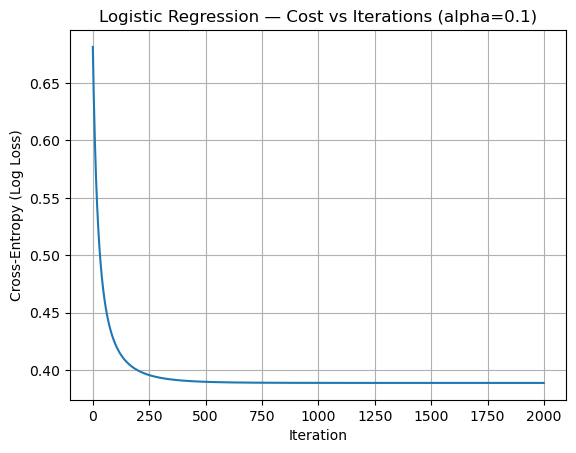

In [11]:
import matplotlib.pyplot as plt

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cross-Entropy (Log Loss)")
plt.title("Logistic Regression — Cost vs Iterations (alpha=0.1)")
plt.grid(True)
plt.show()
